**Question 1: What is Deep Learning? Briefly describe how it evolved and how it differs from traditional machine learning.**
> Deep Learning is a subfield of Machine Learning that involves the use of neural networks to model and solve complex problems. Neural networks are modeled
after the structure and function of the human brain and consist of layers of
interconnected nodes that process and transform data.

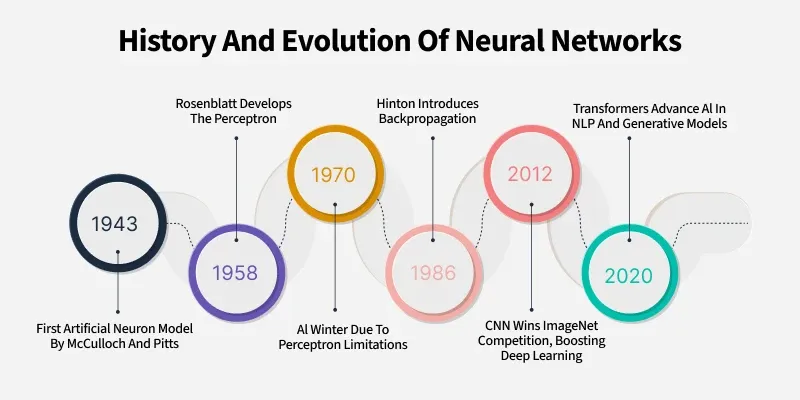

| **Machine Learning** | **Deep Learning** |
|------------------------|-------------------|
| Applies statistical algorithms to learn the hidden patterns and relationships in the dataset. | Uses artificial neural network architecture to learn the hidden patterns and relationships in the dataset. |
| Can work on a smaller amount of dataset. | Requires a larger volume of dataset compared to machine learning. |
| Better for low-label tasks. | Better for complex tasks like image processing, natural language processing, etc. |
| Takes less time to train the model. | Takes more time to train the model. |
| A model is created by relevant features which are manually extracted from images to detect an object in the image. | Relevant features are automatically extracted from images. It is an end-to-end learning process. |
| Less complex and easy to interpret the result. | More complex, it works like a black box — interpretations of the results are not easy. |
| It can work on the CPU or requires less computing power compared to deep learning. | It requires a high-performance computer with GPU. |


**Question 2: Explain the basic architecture and functioning of a Perceptron. What are its limitations?**
> A perceptron is the simplest type of artificial neuron. It takes multiple inputs, multiplies each by a weight, sums them, and applies an activation function.

**Equation:**

            y=f(w1x1 + +W2X2+....b)

            Where:
            Xi: input features
            Wi: weights
            b: bias
            f: activation function

**Limitations:**
* Can only solve linearly separable problems (e.g., AND, OR but not XOR).
* No hidden layers, so limited learning capability.
* Sensitive to learning rate and data scaling.

**Question 3: Describe the purpose of activation functions in neural networks. Compare Sigmoid, ReLU, and Tanh.**

> Activation functions introduce non-linearity, enabling neural networks to learn complex relationships.

| Function    | Equation                                     | Range  | Pros                           | Cons                             |
| ----------- | -------------------------------------------- | ------ | ------------------------------ | -------------------------------- |
| **Sigmoid** | f(x) = 1/(1+e^-x)               | (0,1)  | Smooth, good for probabilities | Vanishing gradients              |
| **Tanh**    | f(x) = (e^x - e^-x)/(e^x + e^-x) | (-1,1) | Centered, faster than sigmoid  | Still vanishes for large values  |
| **ReLU**    | f(x) = max(0, x)                        | [0,∞)  | Efficient, non-saturating      | Dead neurons for negative inputs |


**Question 4: What is the difference between Loss function and Cost function in neural networks? Provide examples.**
> A **loss function** measures the error for a single data point.
            
            y'=(y_true-y_pred)^2
> A **cost function** is the average of the loss function values over the entire dataset.

          J=1/n Sum(y')
          

**Question 5: What is the role of optimizers in neural networks? Compare Gradient Descent, Adam, and RMSprop.**

>The optimizer’s role is to find the best combination of weights and biases that leads to the most accurate predictions.

* **Gradient Decesent:**
    > **Advantage**
  * efficiency for large datasets,
  * simplicity of implementation,
  * adaptability to various
    
  > **Disadvantages**
  * Sensitive to leanring rate
  * Slow convergence
* **Adam**
  > **Advantage**
  * Fast convergence.

  > **Disadvantages**
  * Requires significant memory due to the need to store first and second moment estimates.

* **RMSprop**
  > **Advantage**
  * Prevents excessive decay of learning rates.

  > **Disadvantages**
  * Computationally expensive due to the additional parameter.

    

In [1]:
#Question 6: Python Program – Single-Layer Perceptron for AND Gate

import numpy as np

# Inputs and outputs for AND gate
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,0,0,1])

# Initialize weights and bias
w = np.random.rand(2)
b = np.random.rand()
lr = 0.1

# Activation function
def step(x):
    return 1 if x > 0.5 else 0

# Training
for epoch in range(100):
    for i in range(4):
        z = np.dot(X[i], w) + b
        y_pred = step(z)
        error = y[i] - y_pred
        w += lr * error * X[i]
        b += lr * error

print("Weights:", w)
print("Bias:", b)
print("Predictions:", [step(np.dot(x, w) + b) for x in X])


Weights: [0.32135379 0.35094643]
Bias: 0.11424081639654987
Predictions: [0, 0, 0, 1]


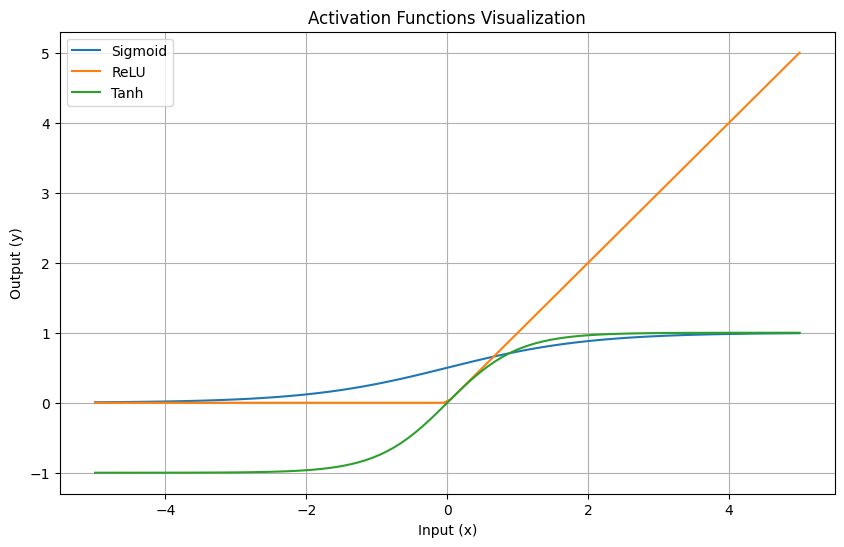

In [2]:
#Question 7: Visualize Sigmoid, ReLU, and Tanh using Matplotlib

import numpy as np
import matplotlib.pyplot as plt

# 1. Define the activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# 2. Generate input data
x = np.linspace(-5, 5, 100) # 100 points between -5 and 5

# 3. Calculate output values
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

# 4. Plot the functions
plt.figure(figsize=(10, 6))

plt.plot(x, y_sigmoid, label='Sigmoid')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_tanh, label='Tanh')

plt.title('Activation Functions Visualization')
plt.xlabel('Input (x)')
plt.ylabel('Output (y)')
plt.grid(True)
plt.legend()
plt.show()

In [3]:
#!pip install tensorflow

In [4]:
# Question 8: Build and Train a Simple NN on MNIST


from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
print("Training Accuracy:", history.history['accuracy'][-1])


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8773 - loss: 0.4403 - val_accuracy: 0.9517 - val_loss: 0.1572
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9648 - loss: 0.1235 - val_accuracy: 0.9685 - val_loss: 0.1006
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9765 - loss: 0.0770 - val_accuracy: 0.9759 - val_loss: 0.0788
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9825 - loss: 0.0578 - val_accuracy: 0.9765 - val_loss: 0.0784
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9789 - val_loss: 0.0707
Training Accuracy: 0.9860833287239075


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7818 - loss: 0.6234 - val_accuracy: 0.8469 - val_loss: 0.4301
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8628 - loss: 0.3849 - val_accuracy: 0.8641 - val_loss: 0.3804
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8729 - loss: 0.3415 - val_accuracy: 0.8699 - val_loss: 0.3686
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8834 - loss: 0.3147 - val_accuracy: 0.8598 - val_loss: 0.3749
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8906 - loss: 0.2951 - val_accuracy: 0.8761 - val_loss: 0.3462


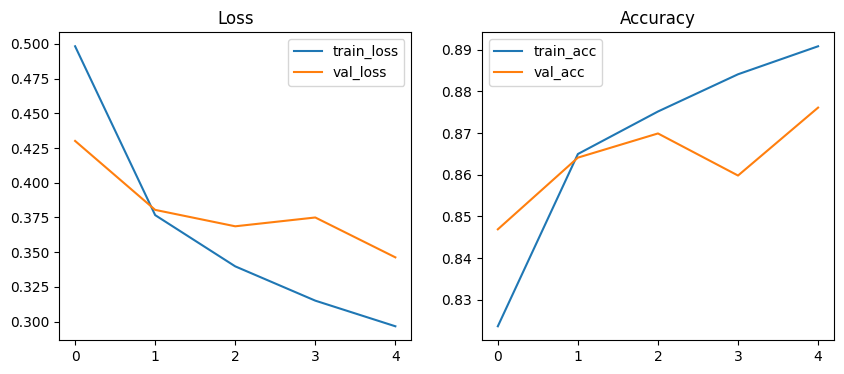

In [5]:
# Question 9: Visualize Loss and Accuracy on Fashion MNIST

from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title('Accuracy')
plt.show()


**Question 10: Fraud Detection Workflow**

* Model Design: Use a multilayer neural network (MLP) with input = structured features, 2 hidden layers (64–128 neurons), and output = 1 neuron (sigmoid).

* Activation Function: Use ReLU in hidden layers and Sigmoid for binary output.

* Loss Function: Binary Cross-Entropy, since it’s a classification task.

* Handling Imbalance:
  * Apply class weights or SMOTE to balance data.
  * Use metrics like AUC-ROC instead of accuracy.

* Optimizer: Adam for adaptive learning rate.

* Prevent Overfitting: Use Dropout, early stopping, and L2 regularization.

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- Step 1: Create a dummy dataset ---
# Suppose we have 10 features and 5000 samples
X = np.random.rand(5000, 10)          # Feature matrix
y = np.random.randint(0, 2, 5000)     # Binary labels (0 or 1)

# --- Step 2: Split into train and test sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Build the model ---
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# --- Step 4: Compile the model ---
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- Step 5: Add early stopping ---
early_stop = EarlyStopping(monitor='val_loss', patience=3)

# --- Step 6: Train the model ---
model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight={0:1, 1:10},   # Example class imbalance handling
    callbacks=[early_stop]
)

# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.2f}")
print(f"Test Accuracy: {accuracy:.2f}")

# view prediction'
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print("Sample Predictions:", y_pred[:10].flatten())



Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4979 - loss: 2.2194 - val_accuracy: 0.5050 - val_loss: 1.1815
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5032 - loss: 1.7190 - val_accuracy: 0.5050 - val_loss: 1.2634
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4971 - loss: 1.7194 - val_accuracy: 0.5050 - val_loss: 1.2550
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5111 - loss: 1.6811 - val_accuracy: 0.5050 - val_loss: 1.2136
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5494 - loss: 1.1130  
Test Loss: 1.18
Test Accuracy: 0.52
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Sample Predictions: [1 1 1 1 1 1 1 1 1 1]
